In [1]:
import numpy as np
from qiskit.quantum_info import DensityMatrix
from qiskit import QuantumCircuit
from qiskit_paulice.noise_models import NoiseModel

import math
import sys
from pathlib import Path

_here = Path().resolve()
for _p in [_here, *_here.parents]:
    _src = _p / "src"
    if (_src / "qudits_on_qubits" / "__init__.py").is_file():
        repo_root = _p
        if str(_src) not in sys.path:
            sys.path.insert(0, str(_src))
        break
else:
    raise ImportError(
        "qudits_on_qubits repo root not found; run the notebook from notebooks/ or the repo root"
    )

from qiskit.quantum_info import Statevector, Operator, partial_trace, SparsePauliOp
from qiskit import qpy, QuantumCircuit
import numpy as np
from qiskit.synthesis import TwoQubitWeylDecomposition
from qiskit_aer import AerSimulator

from qudits_on_qubits import create_ame_circuit, generate_b_ame
from sympy.functions.combinatorial.numbers import legendre_symbol
from IPython.display import display, Math
from itertools import product
from qiskit_aer.primitives import EstimatorV2 as AerEstimator
from qiskit_aer.primitives import SamplerV2 as AerSampler
from qiskit.circuit import QuantumCircuit
from qiskit.circuit.library import StatePreparation
from igraph import Graph, plot
import matplotlib.pyplot as plt

In [2]:
from qudits_on_qubits.bell_measurements.sampler_circuits import build_sampler_circuits_from_graph, build_sampler_circuits_for_candidate
from iqm.qiskit_iqm.fake_backends.fake_garnet import IQMFakeGarnet
from iqm.iqm_client import CircuitCompilationOptions, DDMode, STANDARD_DD_STRATEGY, DDStrategy
from iqm.qiskit_iqm import IQMProvider
from iqm.qiskit_iqm.iqm_naive_move_pass import transpile_to_IQM
from iqm.iqm_client.transpile import ExistingMoveHandlingOptions

from qudits_on_qubits.bell_measurements.sampler_circuits import run_sampler_circuits_to_counts_by_setting
from qudits_on_qubits.bell_measurements.sampler_circuits import decoding_kwargs_from_metadata
from qudits_on_qubits.bell_measurements.postprocessing import compute_bell_value_from_counts

In [3]:
dd_options = CircuitCompilationOptions(
      dd_mode=DDMode.ENABLED,
      dd_strategy=STANDARD_DD_STRATEGY,
  )

dd_default = CircuitCompilationOptions(
      dd_mode=DDMode.ENABLED)

dd_xy4 = CircuitCompilationOptions(
      dd_mode=DDMode.ENABLED,
      dd_strategy=DDStrategy(
          gate_sequences=[(5, "YXYX", "asap")]
      ),
  )

In [20]:
import os
provider_garnet = IQMProvider("https://resonance.iqm.tech/", quantum_computer="garnet", token=os.environ["IQM_TOKEN"])
backend_garnet = provider_garnet.get_backend(use_metrics=True)

In [5]:
from provider import get_backend, get_backend_error_profile, generate_random_error_profile, to_static_architecture
from iqm.qiskit_iqm.fake_backends.iqm_fake_backend import IQMFakeBackend
from iqm.qiskit_iqm.fake_backends.fake_garnet import IQMFakeGarnet

In [6]:
backend = get_backend(quantum_computer="garnet")
error_profile = generate_random_error_profile(backend=backend)

garnet = IQMFakeGarnet()
garnet_architecture = garnet.architecture

static_garnet_architecture = to_static_architecture(garnet_architecture)

static_garnet_architecture = to_static_architecture(garnet_architecture)

garnet_noisy_backend = IQMFakeBackend(architecture=static_garnet_architecture, error_profile=error_profile)

Backend connected successfully, using garnet

Noise profile: random-noise-profile

T1 / T2 / readout
qubit   T1 [us]   T2 [us]  readout 0->1  readout 1->0  readout avg error  readout asymmetry
  QB1 64.372222 45.091733      0.055295      0.048099           0.051697          -0.007196
  QB2 45.473154 40.925838      0.057484      0.050853           0.054169          -0.006631
  QB3 27.121536 21.337651      0.044739      0.045458           0.045098           0.000719
  QB4 37.084528 33.376075      0.046531      0.037212           0.041872          -0.009319
  QB5 67.638786 35.129194      0.024941      0.027981           0.026461           0.003040
  QB6 42.843650 21.265987      0.040377      0.049987           0.045182           0.009610
  QB7 26.757428 24.081686      0.048235      0.041801           0.045018          -0.006435
  QB8 51.034733 16.900568      0.008812      0.013160           0.010986           0.004347
  QB9 32.722458 29.450212      0.033708      0.033657           0.03368

In [7]:
selected_candidate = "monomial_full__sup013_P102_ph022"
#QuditsOnQubits\artifacts\iqm_runs\selected_best\two_qutrit\stage2_top10_rerun20_20260706\exact\rank01_monomial_full__sup023_P012_ph022
artifact_circuit_dir = repo_root / "artifacts" / "iqm_runs" / "raw" / "quantum_circuits" / "garnet" / "two_qutrit" / selected_candidate
legacy_circuit_dir = repo_root.parent / "QuditsOnQubits" / "basis_direct_encoding_benchmarks" / "quantum_circuits" / "two_qutrit" / selected_candidate

for circuit_dir in (artifact_circuit_dir, legacy_circuit_dir):
    if (circuit_dir / "graph_state_direct_basis.qpy").is_file():
        break
else:
    raise FileNotFoundError(
        "Circuit artifacts not found. Checked:\n"
        f"- {artifact_circuit_dir}\n"
        f"- {legacy_circuit_dir}"
    )

print(f"Loading circuits from: {circuit_dir}")

with (circuit_dir / "graph_state_direct_basis.qpy").open("rb") as f:
    testqc = qpy.load(f)[0]

with (circuit_dir / "graph_state_direct_basis_transpiled.qpy").open("rb") as f:
    qcsuptrans = qpy.load(f)[0]

with (circuit_dir / "F3_W.qpy").open("rb") as f:
    F3sup = qpy.load(f)[0]

Esup = np.load(circuit_dir / "E.npy")

Loading circuits from: C:\Users\szymo\QuditsOnQubits\QuditsOnQubits\artifacts\iqm_runs\raw\quantum_circuits\garnet\two_qutrit\monomial_full__sup013_P102_ph022


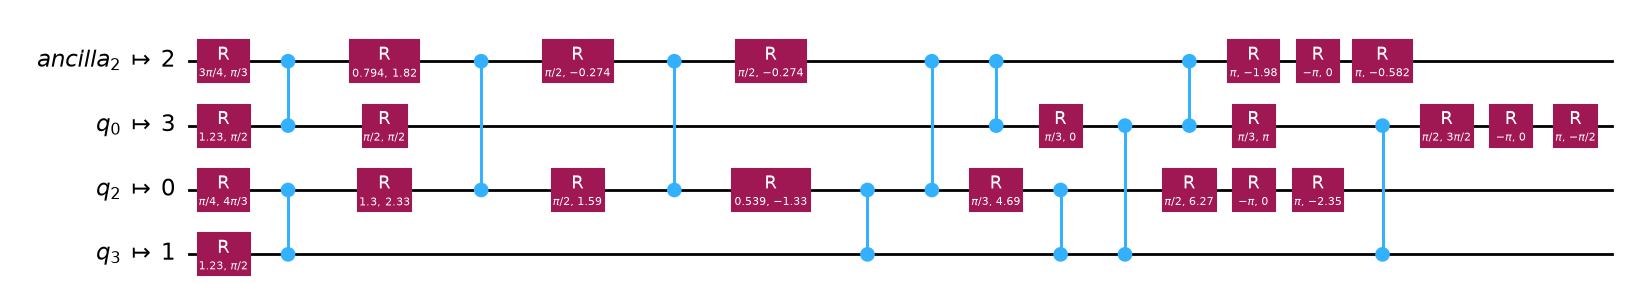

In [8]:
qcsuptrans.draw("mpl")

In [18]:
def fold_cz_preserve_layout(qc: QuantumCircuit, n: int = 3) -> QuantumCircuit:
      if n < 1:
          raise ValueError("n musi byc >= 1")
      if n % 2 == 0:
          raise ValueError("Do ZNE uzyj nieparzystego n: 1, 3, 5, ...")

      out = qc.copy()
      old_data = list(out.data)
      out.data.clear()

      for inst in old_data:
          op = inst.operation
          qargs = inst.qubits
          cargs = inst.clbits

          if op.name.lower() == "cz":
              for _ in range(n):
                  out.append(op.copy(), qargs, cargs)
          else:
              out.append(op.copy(), qargs, cargs)

      out.name = f"{qc.name}_czfold{n}"
      return out

In [26]:
layout = qcsuptrans.layout.final_index_layout(filter_ancillas=True)
qutrit_qubits = ((layout[0], layout[1]), (layout[2], layout[3]))

sampler_circuits, metadata = build_sampler_circuits_for_candidate(candidate="two_qutrit", state_circuit=qcsuptrans, E=Esup, qutrit_qubits=qutrit_qubits)
isa_sampler_qc = [transpile_to_IQM(qc, backend=backend_garnet, optimization_level=3, seed_transpiler=3) for qc in sampler_circuits]

In [27]:
qutrit_qubits

((0, 4), (3, 1))

In [28]:
isa_sampler_qc_1 = isa_sampler_qc
isa_sampler_qc_3 = [fold_cz_preserve_layout(qc, n=3) for qc in isa_sampler_qc]
isa_sampler_qc_5 = [fold_cz_preserve_layout(qc, n=5) for qc in isa_sampler_qc]

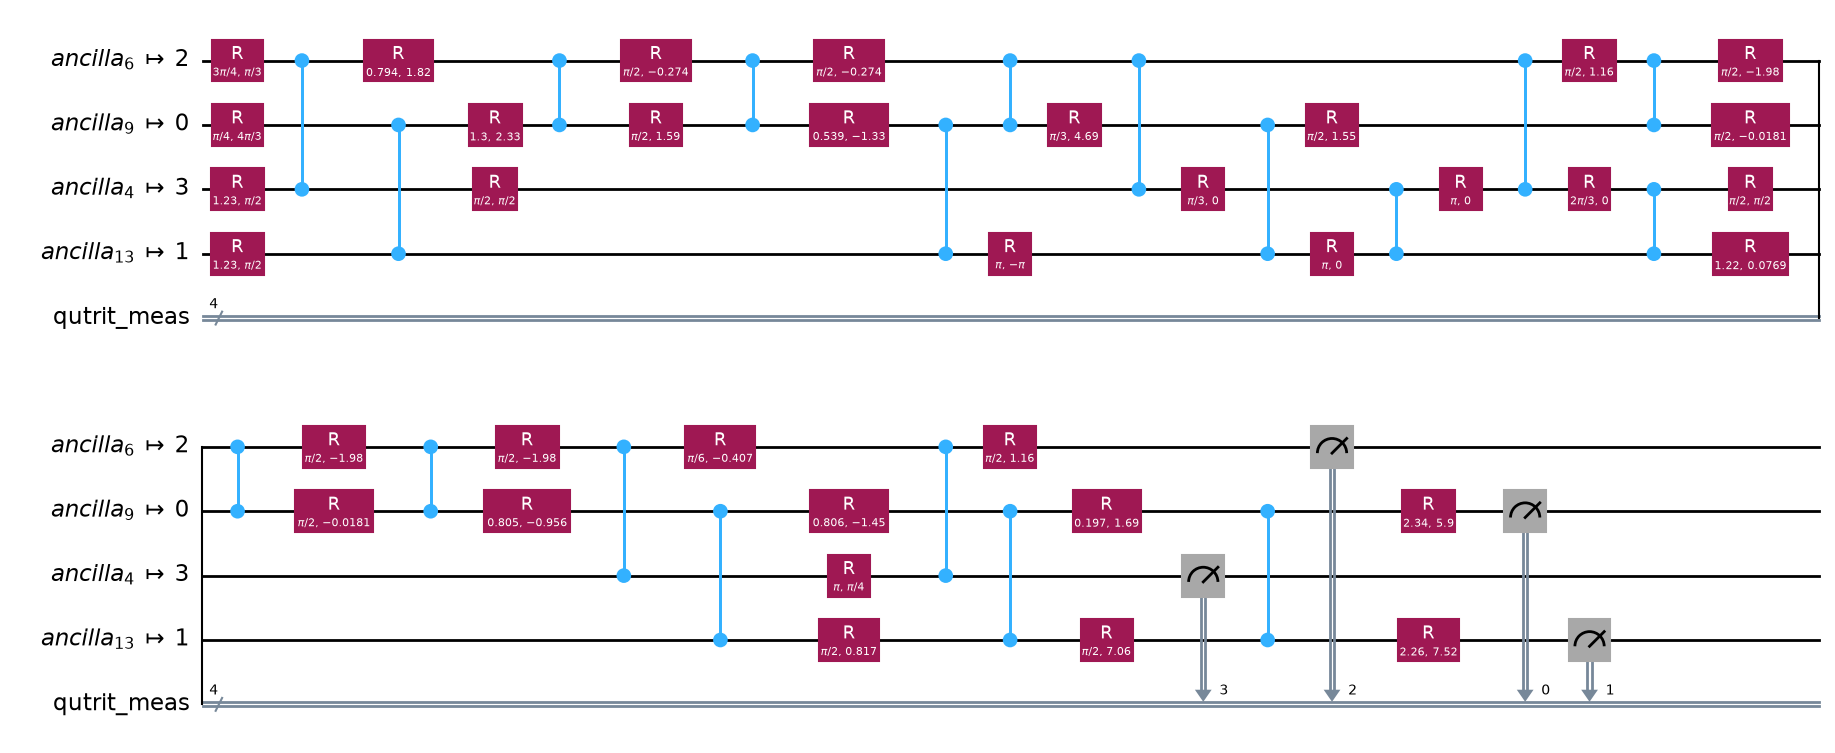

In [25]:
isa_sampler_qc_1[0].draw("mpl")

In [13]:
counts_by_setting, run_info = run_sampler_circuits_to_counts_by_setting(isa_sampler_qc, metadata, shots=1024*20, transpile_circuits=False, backend=AerSampler())
counts_by_setting3, run_info3 = run_sampler_circuits_to_counts_by_setting(isa_sampler_qc_3, metadata, shots=1024*20, transpile_circuits=False, backend=AerSampler())
counts_by_setting5, run_info5 = run_sampler_circuits_to_counts_by_setting(isa_sampler_qc_5, metadata, shots=1024*20, transpile_circuits=False, backend=AerSampler())

In [14]:
bell_value = compute_bell_value_from_counts(counts_by_setting, metadata["terms"], metadata["qutrit_bit_indices_by_setting"], **decoding_kwargs_from_metadata(metadata))
bell_value3 = compute_bell_value_from_counts(counts_by_setting3, metadata["terms"], metadata["qutrit_bit_indices_by_setting"], **decoding_kwargs_from_metadata(metadata))
bell_value5 = compute_bell_value_from_counts(counts_by_setting5, metadata["terms"], metadata["qutrit_bit_indices_by_setting"], **decoding_kwargs_from_metadata(metadata))

bell_value, bell_value3, bell_value5

((5.974409409427464-7.327471962526033e-15j),
 (5.999432961578814-7.424616477180734e-15j),
 (6.007023561912531-7.45931094670027e-15j))

In [29]:
counts_by_setting_garnet, run_info_garnet = run_sampler_circuits_to_counts_by_setting(isa_sampler_qc, metadata, shots=1024*20, transpile_circuits=False, backend=backend_garnet, run_options={"circuit_compilation_options": dd_default})

In [30]:
bell_value = compute_bell_value_from_counts(counts_by_setting_garnet, metadata["terms"], metadata["qutrit_bit_indices_by_setting"], **decoding_kwargs_from_metadata(metadata))

In [31]:
bell_value

(4.91144700328406-6.0021432268797525e-15j)

In [32]:
counts_by_setting_garnet3, run_info_garnet3 = run_sampler_circuits_to_counts_by_setting(isa_sampler_qc_3, metadata, shots=1024*20, transpile_circuits=False, backend=backend_garnet, run_options={"circuit_compilation_options": dd_default})

In [33]:
bell_value3 = compute_bell_value_from_counts(counts_by_setting_garnet3, metadata["terms"], metadata["qutrit_bit_indices_by_setting"], **decoding_kwargs_from_metadata(metadata))

In [34]:
bell_value3

(4.09834110476419-4.989064716909297e-15j)

In [35]:
counts_by_setting_garnet5, run_info_garnet5 = run_sampler_circuits_to_counts_by_setting(isa_sampler_qc_5, metadata, shots=1024*20, transpile_circuits=False, backend=backend_garnet, run_options={"circuit_compilation_options": dd_default})

In [36]:
bell_value5 = compute_bell_value_from_counts(counts_by_setting_garnet5, metadata["terms"], metadata["qutrit_bit_indices_by_setting"], **decoding_kwargs_from_metadata(metadata))

In [37]:
bell_value5

(2.84638847079997-3.1953606427492787e-15j)

In [39]:
scale_factors = np.array([1.0, 3.0, 5.0])
bell_values = np.array([bell_value.real, bell_value3.real, bell_value5.real], dtype=float)

coeff = np.polyfit(scale_factors, bell_values, deg=1)
zne_linear = np.polyval(coeff, 0.0)

In [40]:
zne_linear

np.float64(5.500852758979146)

In [41]:
import mthree

In [42]:
mapping = mthree.utils.final_measurement_mapping(isa_sampler_qc[0])

In [43]:
mapping

{0: 15, 1: 19, 2: 14, 3: 18}

In [44]:
measured_physical_qubits = sorted(set(mapping.values()))
measured_physical_qubits

[14, 15, 18, 19]

In [45]:
from qiskit.circuit import QuantumCircuit
import numpy as np

def build_readout_calibration_matrices(
    backend,
    physical_qubits,
    shots=10_000
):
    """
    Zwraca listę macierzy kalibracyjnych M3.
    Dla kubitów, których nie kalibrujemy, pozostaje None.
    """
    matrices = [None] * backend.num_qubits

    for q in physical_qubits:
        # Przygotowanie |0> i pomiar kubitu q
        cal_0 = QuantumCircuit(backend.num_qubits, 1)
        cal_0.measure(q, 0)

        # Przygotowanie |1> i pomiar kubitu q
        cal_1 = QuantumCircuit(backend.num_qubits, 1)
        cal_1.x(q)
        cal_1.measure(q, 0)

        counts_0, counts_1 = backend.run(
            [cal_0, cal_1],
            shots=shots
        ).result().get_counts()

        # P(odczytano 1 | przygotowano 0)
        p10 = counts_0.get("1", 0) / shots

        # P(odczytano 0 | przygotowano 1)
        p01 = counts_1.get("0", 0) / shots

        # Kolumny: stan przygotowany |0>, |1>
        # Wiersze: stan odczytany  |0>, |1>
        matrices[q] = np.array(
            [
                [1 - p10, p01],
                [p10, 1 - p01]
            ],
            dtype=np.float32
        )

        print(f"Qubit {q}:")
        print(matrices[q])

    return matrices

In [46]:
calibration_matrix = build_readout_calibration_matrices(backend_garnet, measured_physical_qubits, shots=10000)

Qubit 14:
[[0.9728 0.0122]
 [0.0272 0.9878]]
Qubit 15:
[[0.9843 0.0256]
 [0.0157 0.9744]]


Progress in queue:   0%|          | 0/1 [00:00<?, ?it/s]

Qubit 18:
[[0.9818 0.012 ]
 [0.0182 0.988 ]]
Qubit 19:
[[0.9865 0.0107]
 [0.0135 0.9893]]


In [47]:
mit = mthree.M3Mitigation()

mit.cals_from_matrices(calibration_matrix)

def apply_mitigation(counts_by_setting, mit, mapping):
    quasi = []

    for res in list(counts_by_setting.values()):
        quasi.append(mit.apply_correction(res, mapping, return_mitigation_overhead=True))

    quasi_miti = {}

    for i, setting in zip(quasi, list(counts_by_setting.keys())):
        quasi_temp = {}
        for key in i.keys():
            quasi_temp[key] = int(i[key]*1024*20)
        quasi_miti[setting] = quasi_temp

    return quasi_miti

In [48]:
counts_by_setting_garnet_miti = apply_mitigation(counts_by_setting_garnet, mit, mapping)
counts_by_setting_garnet_miti3 = apply_mitigation(counts_by_setting_garnet3, mit, mapping)
counts_by_setting_garnet_miti5 = apply_mitigation(counts_by_setting_garnet5, mit, mapping)

In [50]:
bell_value_miti = compute_bell_value_from_counts(counts_by_setting_garnet_miti, metadata["terms"], metadata["qutrit_bit_indices_by_setting"], **decoding_kwargs_from_metadata(metadata))
bell_value_miti3 = compute_bell_value_from_counts(counts_by_setting_garnet_miti3, metadata["terms"], metadata["qutrit_bit_indices_by_setting"], **decoding_kwargs_from_metadata(metadata))
bell_value_miti5 = compute_bell_value_from_counts(counts_by_setting_garnet_miti5, metadata["terms"], metadata["qutrit_bit_indices_by_setting"], **decoding_kwargs_from_metadata(metadata))

In [53]:
scale_factors = np.array([1.0, 3.0, 5.0])
bell_values = np.array([bell_value_miti.real, bell_value_miti3.real, bell_value_miti5.real], dtype=float)

coeff = np.polyfit(scale_factors, bell_values, deg=1)
zne_linear = np.polyval(coeff, 0.0)

In [54]:
zne_linear

np.float64(5.900940159861949)